# **RFscorer Tutorial: Practical (English)**

This notebook walks through a practical workflow for using `rfscorer`.

Specifically, you will learn the following workflow.

1. Split the data into **training data / test data** chronologically
2. Build **observation data / ground truth data** and fit the model with `fit()`
3. Compute recommendation scores with all **9 models** and compare accuracy
4. Save and load the model with **pickle**

When running on Google Colab, the following setup is required.
- Install `rfscorer`
```python
!pip install rfscorer
```
- Mount Google Drive (when reading/writing files)
```python
from google.colab import drive
drive.mount("/content/drive")
```

---
## **Data Loading and Preprocessing**
Load a public dataset hosted on GitHub directly into a DataFrame via its URL, then split the data in two stages.

- **Time-based split**: split at a reference date, using the past for training and the most recent days for evaluation (reproducing the operational setting of predicting the future from past data)
- **Period split**: divide each dataset into observation data and ground truth data

In [1]:
import pandas as pd

from rfscorer import RecencyFrequencyScorer, split_by_date

In [2]:
# `access_log.csv` is from ohmsha/PyOptBook (MIT License)
# https://github.com/ohmsha/PyOptBook/tree/main/7.recommendation
url = "https://raw.githubusercontent.com/ohmsha/PyOptBook/main/7.recommendation/access_log.csv"
df = pd.read_csv(url)
# Rename to match the RecencyFrequencyScorer default column names (user_col="user", item_col="item", time_col="datetime")
df.columns = ["user", "item", "datetime"]

print("record num:", len(df))
print("user num:", len(df.user.unique()))
print("item num:", len(df.item.unique()))
print("datetime num:", len(sorted(df.datetime.unique())))
print("datetime:", sorted(df.datetime.unique()))
df.head()

record num: 325908
user num: 31443
item num: 87611
datetime num: 8
datetime: ['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08']


,user,item,datetime
0,4,205587,2015-07-04
1,4,748683,2015-07-04
2,4,790055,2015-07-04
3,4,790055,2015-07-04
4,4,764638,2015-07-04


In [3]:
# Split into training data / test data chronologically (operational setting: predict the future from past data)
# df_train: data available at training time (up to 2015-07-07)
# df_test : for evaluation (the prediction target day 2015-07-08)
target_date = "2015-07-07"
gt_date = "2015-07-08"
df_train = df[df.datetime <= target_date]
df_test = df[df.datetime <= gt_date]

print("train record num:", len(df_train), "/ user num:", len(df_train.user.unique()))
print("test  record num: ", len(df_test), "/ user num: ", len(df_test.user.unique()))

train record num: 285975 / user num: 28605
test  record num:  325908 / user num:  31443


In [4]:
# Use split_by_date() to split the training and test data into observation data and ground truth data
# Observation data (the 6 days up to and including the reference date): the period used to compute recency and frequency
# Ground truth data (the 1 day after the reference date): records the occurrence of target events (revisits, purchases, conversions, etc.)
# Align references: training uses fit_date (gt = next day 07-07), evaluation uses target_date (gt = next day 07-08)
fit_date = "2015-07-06"  # reference date for training
df_train_obs, df_train_gt = split_by_date(df_train, fit_date, observation_days=6, gt_days=1)
df_test_obs, df_test_gt = split_by_date(df_test, target_date, observation_days=6, gt_days=1)

print("--- train ---")
print("obs/datetime num:", len(sorted(df_train_obs.datetime.unique())))
print(sorted(df_train_obs.datetime.unique()))
print("gt/datetime num:", len(sorted(df_train_gt.datetime.unique())))
print(sorted(df_train_gt.datetime.unique()))

print("--- test ---")
print("obs/datetime num:", len(sorted(df_test_obs.datetime.unique())))
print(sorted(df_test_obs.datetime.unique()))
print("gt/datetime num:", len(sorted(df_test_gt.datetime.unique())))
print(sorted(df_test_gt.datetime.unique()))

--- train ---
obs/datetime num: 6
['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06']
gt/datetime num: 1
['2015-07-07']
--- test ---
obs/datetime num: 6
['2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07']
gt/datetime num: 1
['2015-07-08']


---
## **Model Building and Visualization**

Estimate the empirical product-choice probability from the training data (`fit`) and build 6 optimization models.

| Model | Type | Constraints |
|--------|------|------|
| `emp` | Empirical (2D) | none |
| `er` / `ef` | Empirical (1D) | none |
| `mr` | Optimization (1D) | Recency monotonicity + convexity |
| `mf` | Optimization (1D) | Frequency monotonicity + concavity |
| `mono` | Optimization (2D) | monotonicity only |
| `mrc` | Optimization (2D) | monotonicity + Recency convexity |
| `mfc` | Optimization (2D) | monotonicity + Frequency concavity |
| `mcc` | Optimization (2D) | monotonicity + Recency convexity + Frequency concavity |

In [5]:
# No arguments since we use the default column names (user_col="user", item_col="item", time_col="datetime")
scorer = RecencyFrequencyScorer()

In [6]:
# === fit ===
# fit_date    : 2015-07-06
# target_date : 2015-07-07
# gt_date     : 2015-07-08
#                    f t g
#                    ^ ^ ^
# 2015-07-01 2 3 4 5 6 7 8
# test       * * * * * * @
# train    * * * * * * @
# *: observation (observation_days=6),  @: ground truth (gt_days=1)
scorer.fit(df_train_obs, df_train_gt, ref=fit_date, recency_limit=6, frequency_limit=15)

scorer.show()  # display data statistics, correlation coefficients, and the empirical product-choice probability table

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  dataset          : obs 252045 rows,  gt 33930 events  (users: 26030,  items: 74811)
  observation      : 2015-07-01 → 2015-07-06
  user×item pairs  : 180840 → 180752  (before → after applying limits)
  target events    : 1597 → 1585  (before → after applying limits)

── Model ─────────────────────────────────────────────
  recency_limit    : 6
  frequency_limit  : 15

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=6,  weighted ρ: -1.0000)
  frequency ρ      :  0.6500  (p=0.0087,  n=15,  weighted ρ:  0.9713)

  Slice ρ by r  [corr(f, P(r,f)),  expected > 0]
    r= 1:   0.9280
    r= 2:   0.9854
    r= 3:   0.7712
    r= 4:   0.9303
    r= 5:   0.6182
    r= 6:   0.4109
  Slice ρ by f  [corr(r, P(r,f)),  expected < 0]
    f= 1:  -0.9

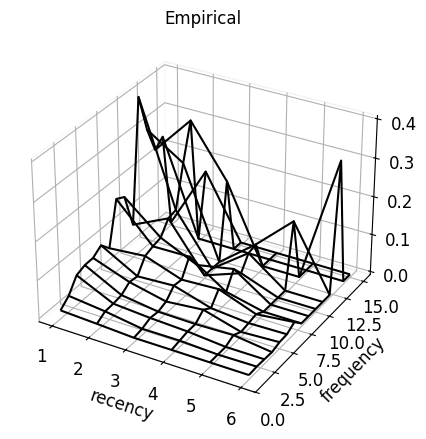

In [7]:
# 3D visualization of the empirical product-choice probability (emp)
# The raw probability table computed directly from the observation data: it contains sampling noise and some cells violate monotonicity
fig_emp = scorer.plot_probability_surface(kind="emp")
fig_emp.savefig("surface_empirical_probability.png")

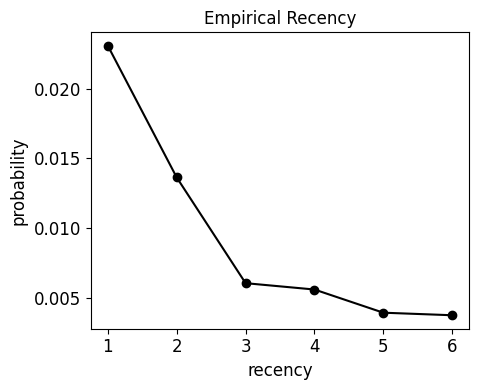

In [8]:
# 1D empirical product-choice probability for recency (er)
# Expected trend: the smaller the recency (more recently viewed), the higher the probability (negative slope)
fig_er = scorer.plot_marginal_probability(kind="er")
fig_er.savefig("marginal_empirical_recency_probability.png")

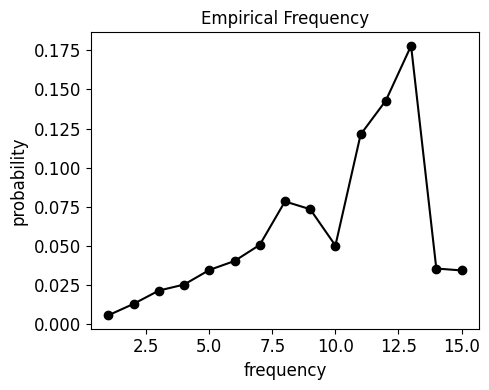

In [9]:
# 1D empirical product-choice probability for frequency (ef)
# Expected trend: the higher the frequency (more views), the higher the probability (positive slope)
fig_ef = scorer.plot_marginal_probability(kind="ef")
fig_ef.savefig("marginal_empirical_frequency_probability.png")

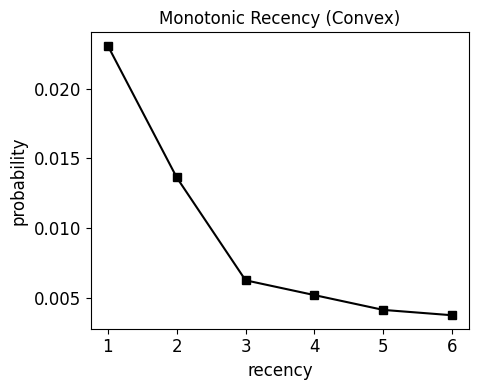

In [10]:
# mr: 1D Recency optimization model (monotonic decreasing + convexity constraint)
# Convexity = the more recent, the larger the drop in probability
scorer.optimize(kind="mr")
fig_mr = scorer.plot_marginal_probability(kind="mr")
fig_mr.savefig("marginal_monotonic_recency_probability.png")

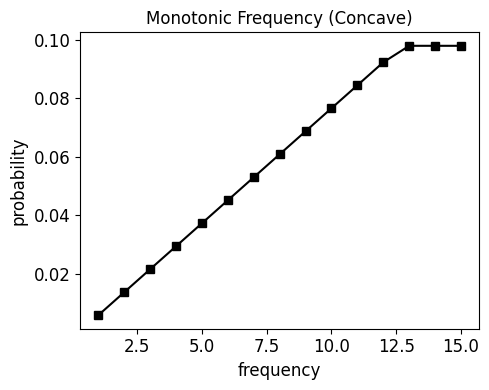

In [11]:
# mf: 1D Frequency optimization model (monotonic increasing + concavity constraint)
# Concavity = the higher the frequency, the smaller the increase in probability
scorer.optimize(kind="mf")
fig_mf = scorer.plot_marginal_probability(kind="mf")
fig_mf.savefig("marginal_monotonic_frequency_probability.png")

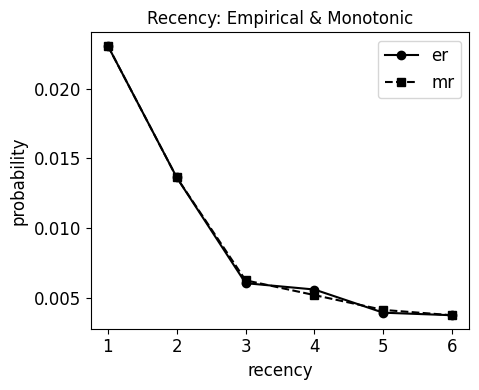

In [12]:
# Overlay the empirical (er) and optimized (mr) Recency probabilities for comparison
# Confirm that optimization removes noise and yields a smooth, monotonic convex curve
fig_rboth = scorer.plot_marginal_probability(kind="rboth")
fig_rboth.savefig("marginal_recencys_probability.png")

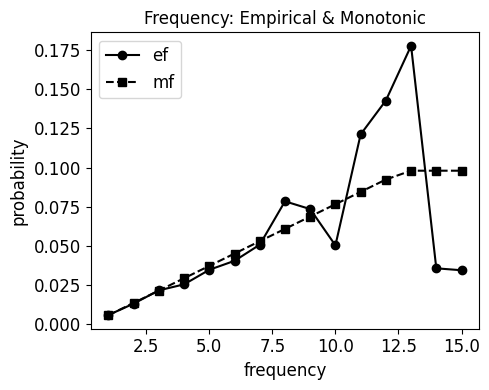

In [13]:
# Overlay the empirical (ef) and optimized (mf) Frequency probabilities for comparison
# Confirm that optimization removes noise and yields a smooth, monotonic concave curve
fig_fboth = scorer.plot_marginal_probability(kind="fboth")
fig_fboth.savefig("marginal_frequencys_probability.png")

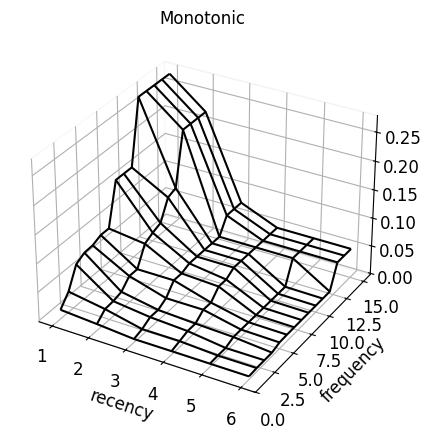

In [14]:
# mono: 2D monotonicity model (Recency monotonic decreasing + Frequency monotonic increasing)
# The simplest 2D optimization model, imposing no convexity/concavity constraints
scorer.optimize(kind="mono")
fig_mono = scorer.plot_probability_surface(kind="mono")
fig_mono.savefig("surface_monotonic_probability.png")

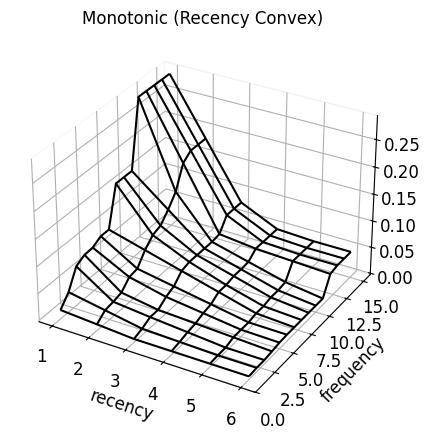

In [15]:
# mrc: monotonicity + Recency convexity constraint
# Convexity = the more recent, the larger the drop in probability (the surface is convex along the Recency axis)
scorer.optimize(kind="mrc")
fig_mrc = scorer.plot_probability_surface(kind="mrc")
fig_mrc.savefig("surface_monotonic_recency_convex_probability.png")

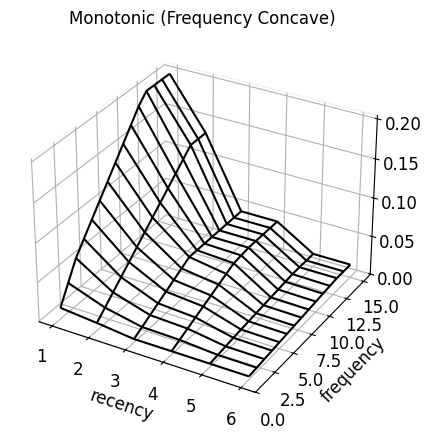

In [16]:
# mfc: monotonicity + Frequency concavity constraint
# Concavity = the higher the frequency, the smaller the increase in probability (the surface is concave along the Frequency axis)
scorer.optimize(kind="mfc")
fig_mfc = scorer.plot_probability_surface(kind="mfc")
fig_mfc.savefig("surface_monotonic_frequency_concave_probability.png")

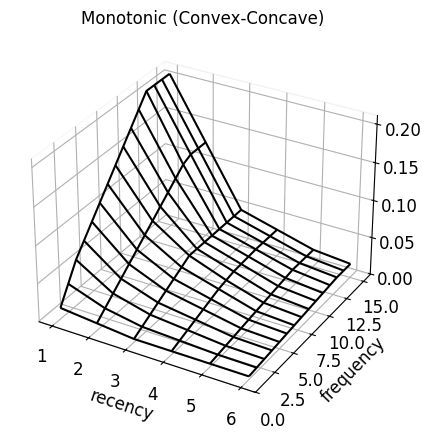

In [17]:
# mcc: monotonicity + Recency convexity + Frequency concavity (the most strongly constrained model)
# Imposing both convexity and concavity simultaneously yields the smoothest surface
scorer.optimize(kind="mcc")
fig_mcc = scorer.plot_probability_surface(kind="mcc")
fig_mcc.savefig("surface_monotonic_convex_concave_probability.png")

In [18]:
# kind="all": export all models (emp/er/ef/mono/mr/mf/mrc/mfc/mcc) combined into a single file
scorer.export_probability_csv(kind="all")

# Export a CSV for each individual model (when you want to reference a model on its own)
kinds = ["er", "ef", "mr", "mf", "emp", "mono", "mrc", "mfc", "mcc"]
for kind in kinds:
    fname = f"prob_{kind}.csv"
    scorer.export_probability_csv(kind=kind, path=fname)

---
## **Generating and Evaluating Recommendations**

Attach every model's probabilities to the test data's observation data (`df_test_obs`) with `transform`,
then compare against the ground truth data (`df_test_gt`) to evaluate recommendation accuracy with `evaluate`.

In [19]:
# Attach each model's predicted product-choice probability and recommendation rank to the test data's observation data df_test_obs
# ref=target_date: compute recency relative to the evaluation point (the operational "today")
kind2df_rec = {kind: scorer.transform(df_test_obs, target_date, kind=kind) for kind in kinds}

In [20]:
# Display the recommendations
for kind in kinds:
    print("---", kind, "---")
    display(kind2df_rec[kind].head(3))

--- er ---


,user,item,recency,frequency,probability,order
71,100,311746,6,1,0.003734,1
72,100,185046,6,1,0.003734,2
73,100,1002465,6,1,0.003734,3


--- ef ---


,user,item,recency,frequency,probability,order
71,100,311746,6,1,0.005897,1
72,100,185046,6,1,0.005897,2
73,100,1002465,6,1,0.005897,3


--- mr ---


...

,user,item,recency,frequency,probability,order
71,100,311746,6,1,0.003436,1
72,100,185046,6,1,0.003436,2
73,100,1002465,6,1,0.003436,3


--- mfc ---


,user,item,recency,frequency,probability,order
71,100,311746,6,1,0.003413,1
72,100,185046,6,1,0.003413,2
73,100,1002465,6,1,0.003413,3


--- mcc ---


,user,item,recency,frequency,probability,order
71,100,311746,6,1,0.003398,1
72,100,185046,6,1,0.003398,2
73,100,1002465,6,1,0.003398,3


In [21]:
# Evaluate the recommendations (order=3: cutoff evaluation at recommendation ranks 1 through 3)
# In addition to precision / recall / f1, output recall_norm / f1_norm normalized by the maximum achievable number of hits
# The last row is the upper bound over all recommendations (the point where recall_norm=1.0)
for kind, df_rec in kind2df_rec.items():
    print("---", kind, "---")
    display(scorer.evaluate(df_rec, df_test_gt, order=3))

--- er ---


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,25380,418,0.016470,0.014097,0.015191,0.210579,0.030550
1,2,48391,680,0.014052,0.022933,0.017427,0.342569,0.026997
2,3,65355,860,0.013159,0.029004,0.018104,0.433249,0.025542
3,288,173703,1985,0.011428,0.066945,0.019523,1.000000,0.022597


--- ef ---


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,25380,505,0.019898,0.017031,0.018353,0.254408,0.036908
1,2,48391,824,0.017028,0.027790,0.021117,0.415113,0.032714
2,3,65355,991,0.015163,0.033422,0.020862,0.499244,0.029433
3,288,173703,1985,0.011428,0.066945,0.019523,1.000000,0.022597


--- mr ---


...

,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,25380,541,0.021316,0.018246,0.019662,0.272544,0.039540
1,2,48391,840,0.017359,0.028330,0.021527,0.423174,0.033349
2,3,65355,1027,0.015714,0.034636,0.021620,0.517380,0.030502
3,288,173703,1985,0.011428,0.066945,0.019523,1.000000,0.022597


--- mfc ---


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,25380,543,0.021395,0.018313,0.019734,0.273552,0.039686
1,2,48391,843,0.017421,0.028431,0.021604,0.424685,0.033468
2,3,65355,1028,0.015729,0.034670,0.021641,0.517884,0.030532
3,288,173703,1985,0.011428,0.066945,0.019523,1.000000,0.022597


--- mcc ---


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,25380,545,0.021474,0.018380,0.019807,0.274559,0.039832
1,2,48391,844,0.017441,0.028464,0.021629,0.425189,0.033508
2,3,65355,1029,0.015745,0.034704,0.021662,0.518388,0.030561
3,288,173703,1985,0.011428,0.066945,0.019523,1.000000,0.022597


In [22]:
# Aggregate and compare precision@1 across all models
# The optimization models (mcc > mfc > mono > mrc) tend to outperform the empirical model (emp)
Rows = []
for kind, df_rec in kind2df_rec.items():
    top = scorer.evaluate(df_rec, df_test_gt, order=1).iloc[0]
    precision = top["precision"]
    recall = top["recall"]
    f1 = top["f1"]
    Rows.append((kind, precision, recall, f1))
df_eval = pd.DataFrame(Rows, columns=["kind", "precision", "recall", "f1"])
df_eval.sort_values("precision", ascending=False)

,kind,precision,recall,f1
8,mcc,0.021474,0.018380,0.019807
7,mfc,0.021395,0.018313,0.019734
5,mono,0.021355,0.018279,0.019698
6,mrc,0.021316,0.018246,0.019662
4,emp,0.020567,0.017605,0.018971
1,ef,0.019898,0.017031,0.018353
3,mf,0.019858,0.016998,0.018317
0,er,0.016470,0.014097,0.015191
2,mr,0.016470,0.014097,0.015191


In [23]:
# Save the recommendations from the mcc model, which had the highest precision@1, to CSV
kind2df_rec["mcc"].to_csv("recommendations.csv", index=False)

In [24]:
# Save the model
scorer.save("rfscorer.pkl")

In [25]:
# Load the model
scorer_loaded = RecencyFrequencyScorer.load("rfscorer.pkl")
scorer_loaded.show()

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  dataset          : obs 252045 rows,  gt 33930 events  (users: 26030,  items: 74811)
  observation      : 2015-07-01 → 2015-07-06
  user×item pairs  : 180840 → 180752  (before → after applying limits)
  target events    : 1597 → 1585  (before → after applying limits)

── Model ─────────────────────────────────────────────
  recency_limit    : 6
  frequency_limit  : 15

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=6,  weighted ρ: -1.0000)
  frequency ρ      :  0.6500  (p=0.0087,  n=15,  weighted ρ:  0.9713)

  Slice ρ by r  [corr(f, P(r,f)),  expected > 0]
    r= 1:   0.9280
    r= 2:   0.9854
    r= 3:   0.7712
    r= 4:   0.9303
    r= 5:   0.6182
    r= 6:   0.4109
  Slice ρ by f  [corr(r, P(r,f)),  expected < 0]
    f= 1:  -0.9

---
## **Additional Features**

This section covers supplementary usage such as customizing column names, fine-tuning plots, retrieving an individual product-choice probability, and saving a zip archive.

In [26]:
# In real-world data the column names are often something other than user/item/datetime
# Specify the column names via the constructor's user_col / item_col / time_col
df_renamed = df.rename(columns={"user": "customer_id", "item": "product_id", "datetime": "date"})
df_train_r = df_renamed[df_renamed.date <= "2015-07-07"]
df_test_r = df_renamed[df_renamed.date <= "2015-07-08"]

scorer_r = RecencyFrequencyScorer(user_col="customer_id", item_col="product_id", time_col="date")
df_obs_r, df_gt_r = split_by_date(
    df_train_r, fit_date, observation_days=6, gt_days=1, time_col="date"
)
scorer_r.fit(df_obs_r, df_gt_r, ref=fit_date, recency_limit=6, frequency_limit=15)

df_test_obs_r, _ = split_by_date(
    df_test_r, target_date, observation_days=6, gt_days=1, time_col="date"
)
scorer_r.optimize(kind="mcc")
scorer_r.transform(df_test_obs_r, target_date, kind="mcc").head()

,customer_id,product_id,recency,frequency,probability,order
71,100,311746,6,1,0.003398,1
72,100,185046,6,1,0.003398,2
73,100,1002465,6,1,0.003398,3
40705,100003,675829,4,1,0.003634,1
40706,100003,979166,4,1,0.003634,2


In [27]:
# predict(r, f): retrieve a single product-choice probability for a specific (recency, frequency) pair
# Compare an item viewed once 1 day ago vs an item viewed twice 2 days ago
for kind in kinds:
    print(
        f"  {kind:4s}: {scorer.predict(1, 1, kind=kind):.6f} v.s. {scorer.predict(2, 2, kind=kind):.6f}"
    )

  er  : 0.023089 v.s. 0.013630
  ef  : 0.005897 v.s. 0.013178
  mr  : 0.023089 v.s. 0.013630
  mf  : 0.005751 v.s. 0.013628
  emp : 0.013819 v.s. 0.022967
  mono: 0.013819 v.s. 0.022967
  mrc : 0.013950 v.s. 0.021801
  mfc : 0.013554 v.s. 0.019616
  mcc : 0.013788 v.s. 0.019243


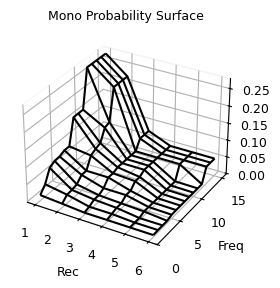

In [28]:
# Adjusting figsize, fontsize, and the axis labels lets you produce plots suited for papers and reports
fig_mono = scorer.plot_probability_surface(
    kind="mono",
    title="Mono Probability Surface",
    figsize=(4, 3),
    fontsize=9,
    recency_label="Rec",
    frequency_label="Freq",
    probability_label="Prob",
)

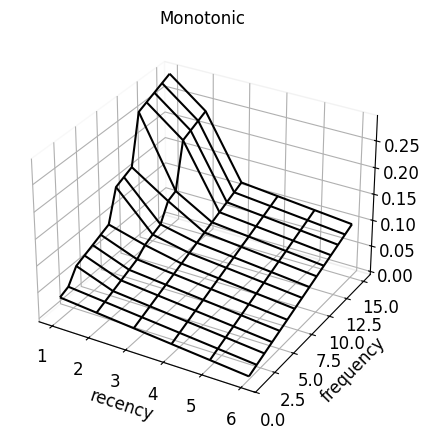

In [29]:
# Set eps to estimate a model with strict monotonic increase/decrease (here eps is set to a large value for clarity)
scorer.optimize(kind="mono", eps=0.007)
fig_mcc = scorer.plot_probability_surface(kind="mono")

In [30]:
# Display information about the optimization computation
scorer.optimize(kind="mcc", verbose=True)

=== show solve info ===
kind: mcc
eps: 0.0
status: optimal
objective_value: 4.4598
elapsed_time: 0.08[s]
num_variables: 90
num_constraints: 477


In [31]:
# save_zip(): bundle pickle + metadata.json + probability table CSVs + plot PNGs into a single zip
# Convenient for sharing among researchers and managing deliverables (storing the probability tables alongside the archive)
scorer.save_zip("scorer.zip")

# load_zip(): restore the model from the zip (the CSV/PNG files are stored inside the zip but are not loaded into Python)
scorer_loaded_zip = RecencyFrequencyScorer.load_zip("scorer.zip")
scorer_loaded_zip.show()

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  dataset          : obs 252045 rows,  gt 33930 events  (users: 26030,  items: 74811)
  observation      : 2015-07-01 → 2015-07-06
  user×item pairs  : 180840 → 180752  (before → after applying limits)
  target events    : 1597 → 1585  (before → after applying limits)

── Model ─────────────────────────────────────────────
  recency_limit    : 6
  frequency_limit  : 15

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=6,  weighted ρ: -1.0000)
  frequency ρ      :  0.6500  (p=0.0087,  n=15,  weighted ρ:  0.9713)

  Slice ρ by r  [corr(f, P(r,f)),  expected > 0]
    r= 1:   0.9280
    r= 2:   0.9854
    r= 3:   0.7712
    r= 4:   0.9303
    r= 5:   0.6182
    r= 6:   0.4109
  Slice ρ by f  [corr(r, P(r,f)),  expected < 0]
    f= 1:  -0.9